<a href="https://colab.research.google.com/github/tegarbimop/klasifikasi-kualitas-beras-cnn/blob/main/Klasifikasi_Kualitas_Beras_CNN_3_Kelas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

print("\nMengekstrak dataset dari Google Drive...")
!unzip -q "/content/drive/MyDrive/Klasifikasi_Kualitas_Beras/archive.zip" -d "/content/temp_dataset/"

source_dir = '/content/temp_dataset/Rice_Image_Dataset'
target_dir = '/content/dataset_3_kelas'

categories = {
    'Kualitas_Paling_Baik': ['Jasmine', 'Ipsala'],
    'Normal': ['Basmati', 'Arborio'],
    'Tidak_Baik': ['Karacadag']
}

print("Memindahkan dan mengelompokkan gambar ke 3 kelas...")
for cat in categories.keys():
    os.makedirs(os.path.join(target_dir, cat), exist_ok=True)

for target_cat, source_folders in categories.items():
    for folder in source_folders:
        src_path = os.path.join(source_dir, folder)
        dst_path = os.path.join(target_dir, target_cat)
        if os.path.exists(src_path):
            files = os.listdir(src_path)
            for f in files:
                shutil.move(os.path.join(src_path, f), os.path.join(dst_path, f))

shutil.rmtree('/content/temp_dataset/')

print("\nSelesai! Verifikasi jumlah gambar per kelas:")
for cat in categories.keys():
    path = os.path.join(target_dir, cat)
    print(f"- {cat.replace('_', ' ')}: {len(os.listdir(path))} gambar")

Mounted at /content/drive

Mengekstrak dataset dari Google Drive...
Memindahkan dan mengelompokkan gambar ke 3 kelas...

Selesai! Verifikasi jumlah gambar per kelas:
- Kualitas Paling Baik: 30000 gambar
- Normal: 30000 gambar
- Tidak Baik: 15000 gambar


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

base_dir = '/content/dataset_3_kelas'

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

print("Memuat Data Training...")
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

print("\nMemuat Data Validation...")
val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax') # 3 output kelas (Paling Baik, Normal, Tidak Baik)
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nMulai proses training model...")
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Memuat Data Training...
Found 60000 images belonging to 3 classes.

Memuat Data Validation...
Found 15000 images belonging to 3 classes.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Mulai proses training model...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2072s 1s/step - accuracy: 0.8407 - loss: 0.3465 - val_accuracy: 0.9765 - val_loss: 0.0716
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2049s 1s/step - accuracy: 0.9570 - loss: 0.1198 - val_accuracy: 0.9791 - val_loss: 0.0635
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2030s 1s/step - accuracy: 0.9691 - loss: 0.0896 - val_accuracy: 0.9961 - val_loss: 0.0129
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2023s 1s/step - accuracy: 0.9777 - loss: 0.0667 - val_accuracy: 0.9967 - val_loss: 0.0093
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2037s 1s/step - accuracy: 0.9821 - loss: 0.0537 - val_accuracy: 0.9944 - val_loss: 0.0156


Model H5 berhasil disimpan!
Saved artifact at '/tmp/tmpay5f8vaq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134111190546000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190545808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190546768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190547536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190547344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190547920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190546576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190548112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190544464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134111190540816: TensorSpec(shape=(), dtype=tf.resource,

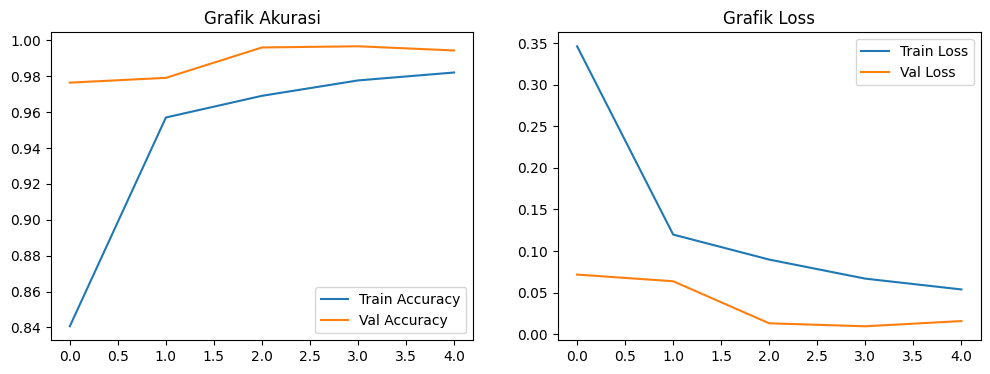


--- TEST PREDIKSI ---
Silakan upload foto butiran beras (disarankan 1 butir atau di zoom dekat)


Saving Arborio (1202).jpg to Arborio (1202).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

File             : Arborio (1202).jpg
Hasil Kualitas   : Normal
Tingkat Keyakinan: 100.00%


In [8]:
model.save('/content/drive/MyDrive/Klasifikasi_Kualitas_Beras/model_beras_cnn_3_kelas.h5')
print("Model H5 berhasil disimpan!")

import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('/content/drive/MyDrive/Klasifikasi_Kualitas_Beras/model_beras_3_kelas.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model TFLite berhasil disimpan!")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Grafik Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss')
plt.legend()
plt.show()

import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

print("\n--- TEST PREDIKSI ---")
print("Silakan upload foto butiran beras (disarankan 1 butir atau di zoom dekat)")
uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    img = image.load_img(path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = model.predict(img_array)
    class_names = list(train_generator.class_indices.keys())

    predicted_class_raw = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    print(f"\n====================================")
    print(f"File             : {fn}")
    print(f"Hasil Kualitas   : {predicted_class_raw.replace('_', ' ')}")
    print(f"Tingkat Keyakinan: {confidence:.2f}%")
    print("====================================")